In [54]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy.io import loadmat
from matplotlib import pyplot as plt
from scipy.stats import norm, nbinom, geom, gamma, fisk, gompertz
from scipy.optimize import minimize

## Doing it myself

- In patchX I need the variable: "patchLength_mean"
- To find patches they look for indices where reward increases from t to t+1, and manually set the first patch as starting from t=1

#### This keeps all patches (longer than 0)

In [80]:
# xPatch-like patchLength_mean (no session exclusion)
root = Path("/Users/tomroper/Projects/Foraging/Leaving Variability/Patch/calvin")
mats = sorted(root.rglob("*.mat"))

trialData = []
for p in mats:
    dataFile = loadmat(str(p), squeeze_me=True, simplify_cells=True)
    data = dataFile["data"]
    for tr in data:
        trialData.append(tr)

choices = np.array([str(tr["choiceMade"]).lower() for tr in trialData], dtype=object)

# Patch boundary = transition stay -> leave
leaveIdx = np.flatnonzero((choices[1:] == "leave") & (choices[:-1] == "stay")) + 1

patches = []
for li in leaveIdx:
    # Count contiguous stays immediately before this leave
    k = li - 1
    stay_count = 0
    while k >= 0 and choices[k] == "stay":
        stay_count += 1
        k -= 1
    patches.append({"length": stay_count})

patchLengths = np.array([p["length"] for p in patches], dtype=float)
patchLengths = patchLengths[patchLengths >= 1]
patchLength_mean = np.nanmean(patchLengths)
raw_trials_total_stays = int(np.nansum(patchLengths))

print("monkey: Calvin")
print("n_sessions:", len(mats))
print("n_patches:", len(patchLengths))
print("n_trials:", raw_trials_total_stays)
print("patchLength_mean:", patchLength_mean)

monkey: Calvin
n_sessions: 33
n_patches: 2025
n_trials: 14413
patchLength_mean: 7.117530864197531


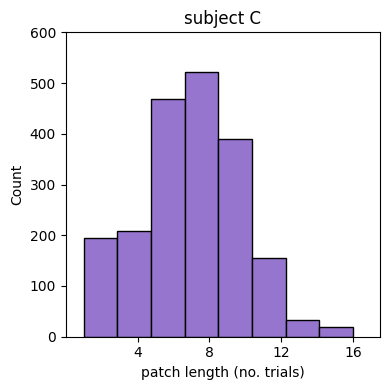

number of patches: 1991
6.896534404821698


In [81]:
x = patchLengths[patchLengths <= 16]

plt.figure(figsize=(4, 4))
plt.hist(x, bins=8, edgecolor="black", color="#9575cd")
plt.ylim(0, 600)
plt.xlim(0, 17.5)
plt.xlabel("patch length (no. trials)")
plt.ylabel("Count")
plt.title(f"subject C")
plt.xticks([4,8,12,16])
plt.tight_layout()
plt.show()
print(f"number of patches: {len(x)}")
print(np.nanmean(x))

#### This removes unfinished patches at end of a session

In [176]:
# Same idea as above, but:
# - compute per session (so the last unfinished patch in a session is ignored)
# - drop any patch that has trialErrors != "none" anywhere inside the patch

root = Path("/Users/tomroper/Projects/Foraging/Leaving Variability/Patch/calvin")
mats = sorted(root.rglob("*.mat"))

patchLengths_all = []
travelTimes_all = []

for p in mats:
    dataFile = loadmat(str(p), squeeze_me=True, simplify_cells=True)
    data = dataFile["data"]

    # print(data[0].keys())

    choices = np.array([str(tr["choiceMade"]).lower() for tr in data], dtype=object)
    errors = np.array([str(tr["trialErrors"]).lower() for tr in data], dtype=object)
    rewards = np.array([float(tr["rewardSize"]) for tr in data], dtype=float)

    # boundary = reward reset upward from trial t -> t+1 (so patch ends at t)
    endIdx = np.flatnonzero(rewards[1:] > rewards[:-1])

    starts = np.r_[0, endIdx[:-1] + 1]

    for s, ei in zip(starts, endIdx):

        # drop patch if any trial in [s..ei] has an error
        # if np.any(errors[s : ei + 1] != "none"):
        #     continue

        # patch residence time = # stay decisions in this patch window
        stay_count = int(np.sum(choices[s : ei + 1] == "stay"))
        if stay_count >= 1:
            patchLengths_all.append(stay_count)

            # travel time BEFORE this patch:
            # - for the first patch in a session: NaN
            # - otherwise: use the leave trial that ended the previous patch (prev_ei)
            # if s == 0:
            #     travelTimes_all.append(np.nan)
            # else:
            #     prev_ei = s - 1  # last trial of previous patch = previous patch's leave trial

            #     current_trial = data[ei]
            #     prev_trial = data[prev_ei]

            #     travel_t = float(current_trial["choiceTime"]) - float(prev_trial["completeTime"])             
            #     travelTimes_all.append(travel_t)
         

patchLengths = np.array(patchLengths_all, dtype=float)
# travelTimes = np.array(travelTimes_all, dtype=float)
patchLength_mean = np.nanmean(patchLengths)
raw_trials_total_stays = int(np.nansum(patchLengths))

print("monkey: Calvin")
print("n_sessions:", len(mats))
print("n_patches:", len(patchLengths))
print("n_trials:", raw_trials_total_stays)
print("patchLength_mean:", patchLength_mean)

monkey: Calvin
n_sessions: 33
n_patches: 2015
n_trials: 14253
patchLength_mean: 7.073449131513648


In [159]:
np.unique(patchLengths[patchLengths <= 4], return_counts=True)

(array([1., 2., 3., 4.]), array([122,  76,  87, 121]))

In [177]:
# travelTimes * 1000

In [178]:
# plt.hist(travelTimes * 1000)

### This graph very similar to the paper

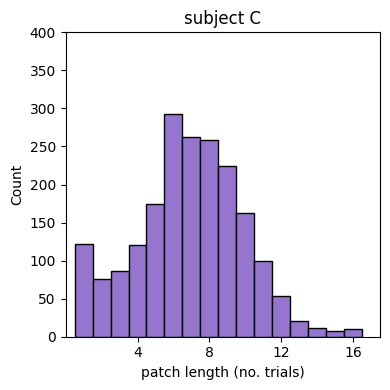

number of patches: 1985
6.877078085642317


In [83]:
x = patchLengths[patchLengths <= 16]

plt.figure(figsize=(4, 4))
edges = np.arange(x.min(), x.max() + 2) - 0.5
_, bin_edges, _ = plt.hist(x, bins=edges, edgecolor="black", color="#9575cd")
plt.ylim(0, 400)
plt.xlim(0, 17.5)
plt.xlabel("patch length (no. trials)")
plt.ylabel("Count")
plt.title(f"subject C")
plt.xticks([4,8,12,16])
plt.tight_layout()
plt.show()
print(f"number of patches: {len(x)}")
print(np.nanmean(x))

- However, the mean does not match even if I remove errors, change the boundary condition, keep unfinished patches or any combo of these choices

In [84]:
np.nanmax(x) - np.nanmin(x)

np.float64(15.0)

In [85]:
print(bin_edges)

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5]


### Checking the likelihood of distributions

To check:
-   negative binomial
-   discrete weibull
-   discrete gamma
-   discrete lognormal
-   geometric
-   beta-geometric

then afterwards I do mixtures and/or 1-inflated. Plus I check for patterns around the 1-stay

In [113]:
patchLengths

array([ 3.,  6.,  4., ...,  8., 15., 10.], shape=(2015,))

In [ ]:
obs = patchLengths

array([ 3.,  6.,  4., ...,  8., 15., 10.], shape=(2015,))

In [116]:
distributions_df = pd.DataFrame()

### Discrete lognormal

In [117]:
def nll_discrete_lognormal(params, x):
    "Negative log likelihood of discrete lognormal distribution"

    # unpack parameters
    mu, sigma = params
    likelihood = np.zeros_like(x)

    # calculate likelihood of observations using discrete lognormal distribution
    # going to do different flow for x=1 to avoid runtime error from log(0)
    mask_1 = (x == 1)

    # first for x not = 1
    mask_not_1 = ~mask_1
    likelihood[mask_not_1] = norm.cdf(np.log(x[mask_not_1]), loc=mu, scale=sigma) - norm.cdf(np.log(x[mask_not_1]-1), loc=mu, scale=sigma)

    # for x = 1 the second term cancels out, and first term log(1) = 0
    likelihood[mask_1] = norm.cdf(0, loc=mu, scale=sigma)
    

    # prevent issues from log(0) due to python rounding down to 0
    likelihood = np.clip(likelihood, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihood))

    return nll

In [118]:
def fit_and_assess_lognormal(x):

    # find an initial guess for parameters(log of observations = normal distribution)
    mu_0 = np.mean(np.log(x))
    sigma_0 = np.std(np.log(x))
    init = [mu_0, sigma_0]
    
    # fit the model to find optimal parameters 
    result = minimize(nll_discrete_lognormal, init, args=(x, ), method="L-BFGS-B")

    # return parameters
    mu_hat, sigma_hat = result.x
    params = {"mu": round(mu_hat, 2), "sigma": round(sigma_hat, 2)}

    # calclate aic and bic 
    N = len(x)
    k = 2
    nll_hat = result.fun 
    
    aic = 2 * k + 2 * nll_hat
    bic = k * np.log(N) + 2 * nll_hat

    return params, aic, bic   

In [119]:
params, aic, bic = fit_and_assess_lognormal(obs)

In [120]:
distributions_df = pd.concat([distributions_df, pd.DataFrame([{"distribution": "discrete lognormal", "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}])], ignore_index=False).drop_duplicates(subset=["distribution"], keep="last")
distributions_df

,distribution,params,aic,bic
0,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73


### Discrete Weibull

It has constraints:
- Q inbetween 0 and 1
- Beta greater than 0

In [121]:
def nll_discrete_weibull(params, x):
    "Negative log likelihood of discrete weibull distribution"

    # unpack parameters
    q, beta = params
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = q ** ((x - 1) ** beta) - q ** (x ** beta)

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

In [122]:
def fit_and_assess_weibull(x):

    # try an initial guess for parameters
    q_0 = 0.5
    beta_0 = 1.0
    init = [q_0, beta_0]

    # we have parameter bounds now 
    bounds = [(1e-9, 1 - 1e-9), #q - baseline leaving tendency
              (1e-9, None)] #beta - beta > 1 means survival probability increases with time, it has memory

    # fit the model to find optimal parameters 
    result = minimize(nll_discrete_weibull, init, args=(x, ), method="L-BFGS-B", bounds=bounds)

    # return parameters
    q_hat, beta_hat = result.x
    params = {"q": round(q_hat, 2), "beta": round(beta_hat, 2)}

    # calclate aic and bic 
    N = len(x)
    k = 2
    nll_hat = result.fun 
    
    aic = 2 * k + 2 * nll_hat
    bic = k * np.log(N) + 2 * nll_hat

    return params, aic, bic

In [123]:
params, aic, bic = fit_and_assess_weibull(obs)

In [124]:
distributions_df = pd.concat([distributions_df, pd.DataFrame([{"distribution": "discrete weibull", "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}])], ignore_index=False).drop_duplicates(subset=["distribution"], keep="last")
distributions_df.sort_values(by="aic")

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.95}",10616.23,10627.45
0,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73


### Negative Binomial

In [125]:
def nll_negative_binomial(params, x):
    "Negative log likelihood of negative binomial distribution"

    # unpack parameters
    r, p = params # r = number of failures, p = probability of success
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = nbinom.pmf(x-1, r, p)  # x-1 because x starts at 1, already discretised no p(x) - p(x-1) needed

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

In [126]:
def fit_and_assess_negative_binomial(x):

    # try an initial guess for parameters
    r_0 = 1.0
    p_0 = 0.5
    init = [r_0, p_0]

    # we have parameter bounds now 
    bounds = [(1e-9, None), # r > 0
              (1e-9, 1 - 1e-9)] # 0 < p < 1

    # fit the model to find optimal parameters 
    result = minimize(nll_negative_binomial, init, args=(x, ), method="L-BFGS-B", bounds=bounds)

    # return parameters
    r_hat, p_hat = result.x
    params = {"r": round(r_hat, 2), "p": round(p_hat, 2)}

    # calclate aic and bic 
    N = len(x)
    k = 2
    nll_hat = result.fun 
    
    aic = 2 * k + 2 * nll_hat
    bic = k * np.log(N) + 2 * nll_hat

    return params, aic, bic

In [127]:
params, aic, bic = fit_and_assess_negative_binomial(obs)
distributions_df = pd.concat([distributions_df, pd.DataFrame([{"distribution": "negative_binomial", "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}])], ignore_index=False).drop_duplicates(subset=["distribution"], keep="last")
distributions_df.sort_values(by="aic")

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.95}",10616.23,10627.45
0,negative_binomial,"{'r': 5.88, 'p': 0.49}",10621.72,10632.93
0,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73


### Geometric

In [128]:
def nll_geometric(params, x):
    "Negative log likelihood of the geometric distribution"

    # unpack parameters
    p = params #p = probability of success
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = geom.pmf(x, p) 

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

In [129]:
def fit_and_assess_geometric(x):

    # try an initial guess for parameters
    p_0 = 0.5
    init = [p_0]

    # we have parameter bounds now 
    bounds = [(1e-9, 1 - 1e-9)] # 0 < p < 1

    # fit the model to find optimal parameters 
    result = minimize(nll_geometric, init, args=(x, ), method="L-BFGS-B", bounds=bounds)

    # return parameters
    p_hat = result.x[0]
    params = {"p": round(p_hat, 2)}

    # calclate aic and bic 
    N = len(x)
    k = 1
    nll_hat = result.fun 
    
    aic = 2 * k + 2 * nll_hat
    bic = k * np.log(N) + 2 * nll_hat

    return params, aic, bic

In [130]:
params, aic, bic = fit_and_assess_geometric(obs)
distributions_df = pd.concat([distributions_df, pd.DataFrame([{"distribution": "geometric", "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}])], ignore_index=False).drop_duplicates(subset=["distribution"], keep="last")
distributions_df.sort_values(by="aic")

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.95}",10616.23,10627.45
0,negative_binomial,"{'r': 5.88, 'p': 0.49}",10621.72,10632.93
0,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73
0,geometric,{'p': 0.14},11616.75,11622.36


### Gamma discretised

In [131]:
def nll_gamma(params, x):
    "Negative log likelihood of the gamma distribution"

    # unpack parameters
    a, s = params # a = shape, s = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = gamma.cdf(x, a, scale=s) - gamma.cdf(x-1, a, scale=s)  # now we need to discretise again

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def fit_and_assess_gamma(x):

    # try an initial guess for parameters
    a_0 = 0.9
    s_0 = 1.0
    init = [a_0, s_0]

    # we have parameter bounds now 
    bounds = [(1e-9, None), # a > 0
              (1e-9, None)] # s > 0

    # fit the model to find optimal parameters 
    result = minimize(nll_gamma, init, args=(x, ), method="L-BFGS-B", bounds=bounds)

    # return parameters
    a_hat, s_hat = result.x
    params = {"a": round(a_hat, 2), "s": round(s_hat, 2)}

    # calclate aic and bic 
    N = len(x)
    k = 2
    nll_hat = result.fun 
    
    aic = 2 * k + 2 * nll_hat
    bic = k * np.log(N) + 2 * nll_hat

    return params, aic, bic

params, aic, bic = fit_and_assess_gamma(obs)
distributions_df = pd.concat([distributions_df, pd.DataFrame([{"distribution": "discrete gamma", "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}])], ignore_index=False).drop_duplicates(subset=["distribution"], keep="last")
distributions_df.sort_values(by="aic")

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.95}",10616.23,10627.45
0,negative_binomial,"{'r': 5.88, 'p': 0.49}",10621.72,10632.93
0,discrete gamma,"{'a': 2.82, 's': 2.33}",10795.95,10807.17
0,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73
0,geometric,{'p': 0.14},11616.75,11622.36


### Log-logistic discretised

In [132]:
def nll_log_logistic(params, x):
    "Negative log likelihood of the discretised log-logistic distribution"

    # unpack parameters
    k, lambda_ = params # k = shape, lambda_ = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = fisk.cdf(x, k, scale=lambda_) - fisk.cdf(x-1, k, scale=lambda_)  

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def fit_and_assess_log_logistic(x):

    # try an initial guess for parameters
    k_0 = 0.9
    lambda_0 = 1.0
    init = [k_0, lambda_0]

    # we have parameter bounds now 
    bounds = [(1e-9, None), # k > 0
              (1e-9, None)] # lambda_ > 0

    # fit the model to find optimal parameters 
    result = minimize(nll_log_logistic, init, args=(x, ), method="L-BFGS-B", bounds=bounds)

    # return parameters
    k_hat, lambda_hat = result.x
    params = {"k": round(k_hat, 2), "lambda_": round(lambda_hat, 2)}

    # calclate aic and bic 
    N = len(x)
    k = 2
    nll_hat = result.fun 
    
    aic = 2 * k + 2 * nll_hat
    bic = k * np.log(N) + 2 * nll_hat

    return params, aic, bic

params, aic, bic = fit_and_assess_log_logistic(obs)
distributions_df = pd.concat([distributions_df, pd.DataFrame([{"distribution": "discrete log-logistic", "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}])], ignore_index=False).drop_duplicates(subset=["distribution"], keep="last")
distributions_df.sort_values(by="aic")

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.95}",10616.23,10627.45
0,negative_binomial,"{'r': 5.88, 'p': 0.49}",10621.72,10632.93
0,discrete gamma,"{'a': 2.82, 's': 2.33}",10795.95,10807.17
0,discrete log-logistic,"{'k': 2.83, 'lambda_': 6.08}",11009.73,11020.94
0,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73
0,geometric,{'p': 0.14},11616.75,11622.36


### Gompertz discretised

In [133]:
def nll_gompertz(params, x):
    "Negative log likelihood of the discretised gompertz distribution"

    # unpack parameters
    eta, beta = params # eta = shape, beta = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = gompertz.cdf(x, eta, scale=beta) - gompertz.cdf(x-1, eta, scale=beta)  

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def fit_and_assess_gompertz(x):

    # try an initial guess for parameters
    eta_0 = 0.9
    beta_0 = 1.0
    init = [eta_0, beta_0]

    # we have parameter bounds now 
    bounds = [(1e-9, None), # eta > 0
              (1e-9, None)] # beta > 0

    # fit the model to find optimal parameters 
    result = minimize(nll_gompertz, init, args=(x, ), method="L-BFGS-B", bounds=bounds)

    # return parameters
    eta_hat, beta_hat = result.x
    params = {"eta": round(eta_hat, 2), "beta": round(beta_hat, 2)}

    # calclate aic and bic 
    N = len(x)
    k = 2
    nll_hat = result.fun 
    
    aic = 2 * k + 2 * nll_hat
    bic = k * np.log(N) + 2 * nll_hat

    return params, aic, bic

params, aic, bic = fit_and_assess_gompertz(obs)
distributions_df = pd.concat([distributions_df, pd.DataFrame([{"distribution": "discrete gompertz", "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}])], ignore_index=False).drop_duplicates(subset=["distribution"], keep="last")
distributions_df.sort_values(by="aic")

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.95}",10616.23,10627.45
0,negative_binomial,"{'r': 5.88, 'p': 0.49}",10621.72,10632.93
0,discrete gamma,"{'a': 2.82, 's': 2.33}",10795.95,10807.17
0,discrete log-logistic,"{'k': 2.83, 'lambda_': 6.08}",11009.73,11020.94
0,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73
0,geometric,{'p': 0.14},11616.75,11622.36
0,discrete gompertz,"{'eta': 0.41, 'beta': 6.2}",12123.02,12134.24


### Drawing the winning distribution over the data

In [107]:
eta = 0.15
beta = 3.72

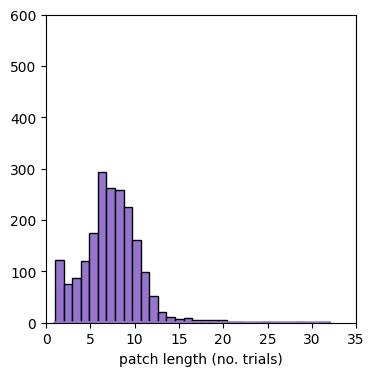

In [ ]:
unique_int = np.arange(1, obs.max() + 1)
likelihoods = gompertz.cdf(unique_int, eta, scale=beta) - gompertz.cdf(unique_int-1, eta, scale=beta)  

plt.figure(figsize=(4, 4))
plt.hist(obs, bins=32, edgecolor="black", color="#9575cd")
# plt.plot(unique_int, unique_int * likelihoods, color="#9575cd", linewidth=2)
plt.ylim(0, 600)
plt.xlim(0, 35)
plt.xlabel("patch length (no. trials)")
plt.show()

In [153]:
np.nanmax(obs)

np.float64(32.0)

In [149]:
_, counts = np.unique(obs[obs <= 4], return_counts=True)
counts

array([122,  76,  87, 121])